# Chapter 8: Color Image Processing

Image processing techniques we have studied so far involve gray scale images of a single channel. We mentioned that most of the image processing techniques can be trivially extended into color images. For example, we can apply smoothing and sharpening filters to three channels of an RGB image to enhance it. Similarly, we can take the transform of each individual channel of a color image to compress it. However, color is a very crucial concept, which deserves special attention, because it provides a great deal of information about the image content.


In [6]:
%%HTML

<figure><p align="center"><iframe width="560" height="315" src="https://www.youtube.com/embed/af78RPi6ayE" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p><figcaption>Video 1: The Physics and Psychology of Colour - Andrew Hanson</figcaption></figure>
  




  

Consider the image of Figure 1.a and b. By changing the color content, we can entirely change the context of the image. While Figure 1.a shows an image of a tiger in the forests, Figure 1.b shows an image of a cat on a rug.

  

In order to use the power of color in image processing algorithms, first, we need to understand the concept of color. Then, we need to find a mathematical representation of colors and relationship among them. In the light of this formalism, we can further improve our algorithms and/or develop new ones for analyzing and processing color images.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image9_new.png" height=300px><figcaption> Figure 1: a) Tiger in forest, b) cat on a rug</figcaption></p></figure>

  

In this chapter, we study color, in particular its physical and cognitive definitions. We, also, introduce mathematical representation of colors. Finally, we study some basic image processing techniques, which incorporate color information. Let us start by answering the most crucial question:

**Motivating Question:** What is color?

  
Color is a very complex concept that we do not yet exactly know how it is generated and how it is perceived by humans, animals and plants. Color is widely studied, in [Color Science](https://en.wikipedia.org/wiki/Color), which is beyond the scope of this course. In this chapter, we suffice to study color,  from two perspective:

-  Color as electromagnetic waveform, in Physics,

-  Color sensation, as we perceive by our Human Visual System.

  

Let us try to describe the concept of color, very  briefly.



In [7]:
%%HTML
<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/0DXZvcfPVrk" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p><figcaption>Video 2: “What is color?” from Khan Academy.</figcaption></figure>


## Color as an Electromagnetic Waveform

  

In physics, there is, barely, nothing called color. Instead, we have a phenomenon, called the electromagnetic spectrum, which consists of waveforms of varying wavelength and energy. The concept of color can be associated by the wavelengths of the visible band of the [electromagnetic spectrum](https://en.wikipedia.org/wiki/Electromagnetic_spectrum), called light. This tiny band covers 7% of the spectrum between approximately 400-800 nanometers, as shown in Figure 1. Although we cannot see the color of objects without light, the light does not create color sensation by itself.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image1_tolu.png" height=190px><figcaption>Figure 2: Wavelengths comprising visible range of the electromagnetic spectrum (Courtesy of General Electric Co., Lamp Business Division).</figcaption></p></figure>

  


In [8]:
%%HTML
<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/0vJOkO43KI4" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p>  <figcaption>Video 3: Color Spectrum</figcaption></figure>


There are three major stages, which generates the color of an object:

  
  

**1. The source of illumination:** The sun or any device generates electromagnetic waveforms with a wide range of wavelengths and energy, depending on the characteristics of the source. This spectrum of signals illuminates the objects together with its surrounding environment.

  

**2. The spectral reflectance of the object's surface:** The electromagnetic waveforms ([photons](https://en.wikipedia.org/wiki/Photon)) hit the surface of an object and bounce back with a new spectrum. The material of the object determines how the surface changes the received spectrum into the radiated spectrum.

  

**3. The characteristics of the sensory device:** Some of the radiated spectrum is captured by a sensory device, such as an eye or an image acquisition device. The dynamic range of the sensory device determines the spectral sensitivity to capture the irradiated spectrum and produce a set of colors, according to a color generation model. Figure 4 shows the three stages of color generation.



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W8/L8_f3.png" height=400px><figcaption>Figure 4: Three stages of color generation. A source generates the light. The light is reflected from an object surface. The irradiated spectrum is captured by a sensory device. </figcaption></p></figure>

  

The initial stage of color perception is the illumination of a physical object under a light source.Therefore, in order to define color, the first step is to define a normative light, which is called the **white light.** Then, we can define the color of an object relative to white light.

  

**Definition: White light** is composed of approximately equal energy in all wavelengths of the visible spectrum.

  
  

**Motivating Question:** What is blue?

  

A blue object has a surface material that reflects the electromagnetic signal with wavelengths corresponding to blue range, when illuminated by white light.

  <figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W8/c8f3.jpg" height=400px><figcaption>Figure 5: a) Yellow cube and  white sphere under a white light source. b) Yellow cube and  white sphere under  a blue light source. c) Yellow cube and white sphere under a yellow light source. d) Blue, red and yellow cubes under a standard desk lamp light source. e) Blue, red, and yellow cubes under a blue lamp. f) Blue, red and yellow cubes under a red lamp. g) Blue, red and yellow cubes under a yellow lamp. </figcaption></p></figure>


A “blue” object does not look blue under, say, red light, but rather purple. Therefore, when we say “the object is blue”, we a priori assume that the illuminating light source is white. Figure 5 illustrates the change in the object color under different illumination conditions.

  

**Motivating Question:** When we define “blue” color above, we already assume that the range of electromagnetic spectrum with the wavelength is approximately 400-500 nanometers. Why do we call an electromagnetic spectrum of a certain range **blue**? How do we split the electromagnetic spectrum into the codes of color, such as **red, green, yellow, purple** etc?

  

The answer to the above question heavily depends on the cognitive properties of the visual perception. Most of the image acquisition devices simulate the color models, which is consistent with the human perception of color.

  

Let's revisit the human visual system from the color generation perspective.



## Color sensation as we perceive by our Human Visual System
  

The above model for color generation does not yet explain how we partition the visible light, which consists of infinitely many wavelengths in a tiny band of electromagnetic spectrum, into a set of color codes.

  

**Motivating Question:** How does the human visual system process the irradiated light from the objects to generate color?

  

Recall that, light reflected from an object filtered in our retina by three types of cones. The response curves of the cones are shown in Figure 5. Millions of cones in the retina filter out the light irradiated from an object to generate 3 types of outputs. In other words, the cones convert the light of a wide range of wavelengths and energy into three different outputs. These outputs are coded into three primary colors, at the lower layers of retina. Then, the coded primary colors are combined by various processes in the brain to generate the other colors.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image2.png" height=300px><figcaption>Figure 5: The response curves of three types of cones which are sensitive to ,short (S), medium (M), and long (L) wavelengths of light. </figcaption></p></figure>

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image3.png" height=300px><figcaption>Figure 6: Millions of rods and cones scattered all over the retina work as tiny filters, each of which pass a certain wavelength of light and digitize a scene reflected on it. The cones filter out the light and code three primary colors at the output. The rods filter out simple shapes. </figcaption></p></figure>

  
  

The cognitive process for generating millions of colors from the three [primary colors](https://en.wikipedia.org/wiki/Primary_color) is not well-understood. However, experimental evidence indicate that the very complicated processes in our brain

-  mixes  the codes of three primary colors to generate the other colors

-  takes the difference of the two spatially neighboring color codes to assign the color of an object.

  

Roughly speaking, we can define the colors as a set of codes generated by our human brain, by mixing the primary colors and taking the differences between the spatially neighboring colors.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image7.png" height=300px><figcaption>Figure 7: We do not exactly know how the color codes are generated in the brain. But, experimental psychology shows that we perceive the color differences, not the colors themselves. The two pink colors are exactly the same, in the above. We perceive them differently, because the backgrounds are different. </figcaption></p></figure>



In [9]:
%%HTML
<figure><p align="center">
<iframe width="560" height="315" src="https://www.youtube.com/embed/l8_fZPHasdo" frameborder="0" allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></p><figcaption>Video 4: How does the brain generate color?</figcaption></figure>



Most of the mathematical models for representing the colors are based on the above findings of the Human Visual System. Three primary colors are used to generate the rest of the colors, in the image acquisition and display devices.

  

Color operations, such as addition, subtraction, measuring the similarity between the colors are based on the [Trichromatic Theory](https://en.wikipedia.org/wiki/Trichromacy) of color vision, suggested by [Thomas Young](https://en.wikipedia.org/wiki/Thomas_Young_(scientist)) and [Hermann von Helmholtz](https://en.wikipedia.org/wiki/Hermann_von_Helmholtz). They propose that the three types of cones generate the color codes for short, medium and long wavelengths of the visible spectrum. These primary color codes are conveyed to the brain, for further processing to create millions of colors. They suggest that three colors are sufficient to generate a color space spanned by the primary colors.



## Mathematical Representation of Color Systems

  

There is a wide range of color systems, suggested in Color Science. Most of them are based on the [Trichromatic Theory](https://en.wikipedia.org/wiki/Trichromacy), which utilizes three primary colors, which span a color space. The selection of the primary colors and the space spanned by these colors depends on the application domain. In the following, we introduce popular color systems.


### RGB Color System

  

RGB color system is the most widely used color model, used in optic cameras, monitors and a wide range of image acquisition devices. It has the primary colors as red ( R ), green (G) and blue (B). In RGB color space, the color $c_i$, of each pixel is represented by a three dimensional vector:

  

$$c_i = \begin{bmatrix}r_i\\ g_i \\ b_i \end{bmatrix},$$

  
  

The range of the elements, $r_i, g_i, b_i$ of this three dimensional vector depends on the bit allocation for each pixel. For example, for an 8 bits per pixel image, the range for each element is $[0, 255]$. The three primary colors of RGB color space is defined as red, green and blue, each of which is represented by,

  

$$r = \begin{bmatrix}255\\ 0 \\ 0 \end{bmatrix}, \qquad g = \begin{bmatrix}0\\ 255 \\ 0\end{bmatrix}, \qquad b = \begin{bmatrix}0\\ 0 \\ 255\end{bmatrix}.$$

  

The RGB color space is spanned by these basis vectors to generate the rest of the colors.

  

**Note:** The space is to be restricted on a color cube. Thus, it is not a vector space. When we apply arithmetic or matrix operations to the color vectors, we need to normalize the output of the operation, so that all the color vectors consist of integer numbers, in the range of allocated bits.

  

For practical reasons, the colors in the cube are normalized to define standard bases, in an interval $[0,1]$, as follows;

  

$$r = \begin{bmatrix}1\\ 0 \\ 0 \end{bmatrix}, \qquad g = \begin{bmatrix}0\\ 1 \\ 0\end{bmatrix}, \qquad b = \begin{bmatrix}0\\ 0 \\ 1\end{bmatrix}.$$

  

The above three-dimensional representation of primary colors forms a standard basis for the color space.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image13.png" height=300px><figcaption>Figure 8: Normalized RGB Color cube in RGB color space. </figcaption></p></figure>

  
  
  

RGB system is called an **additive color system**. The rest of the colors are defined by adding to the black color.

  
  

Figure 9 shows the normalized color cube, in the RGB space. The black and white colors are represented by

  

$$\text black = \begin{bmatrix}0\\ 0 \\ 0 \end{bmatrix} \text{and} \quad \text white = \begin{bmatrix}1\\ 1 \\ 1 \end{bmatrix},$$

  

respectively. In the RGB color space, the coordinates corresponding to black and white show the origin and the diagonal vertex of the color cube. The other 3 vertices correspond to red, green and blue colors.

  

**Note:** In the RGB color cube, the diagonal line between the black, at the origin $(0, 0, 0)$ and the white, at the most distant vertex (1, 1, 1), consists of gray values only. The images with the pixels values lying on this line are just monochromatic. This axis is called the **intensity axis**.

  
  

Theoretically, we can define infinitely many colors within the RGB color cube, as indicated in Figure 9.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image15.png" height=300px><figcaption>Figure 9: RGB color cube with continuous colors. </figcaption></p></figure>

  
  

In practice the number of colors are to be finite. Therefore, we need to quantify the infinitely many points that lie within the cube into a set of finite points. This requires the quantization of the color cube according to the allocated bits per pixel. Figure 10 shows a color cube quantized to generate 6x6x6 = 216 colors.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image16.png" height=300px><figcaption>Figure 10: RGB color cube quantized for generating 216 colors. This color space is called RGB-safe color space. </figcaption></p></figure>

  

In the above representation of the RGB color system, the color of each pixel is represented by the coordinates of three primary colors in three dimensional color space. This representation allows us to decompose a color image into three monochrome images. The pixel values, at each image represent the coordinate of one of the three primary color basis, $r_i , g_i$ and $b_i$. Figure 11.a shows the generation of an RGB image by mixing three monochrome images. Figure 11. b shows the three surfaces of the color cube, when R=0, G=0 and B=0, respectively.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image17.png" height=600px><figcaption>Figure 11: (a) Generating the RGB image of the cross sectional color plane (127,G,B). (b) The three surface planes of the color cube of Figure 10. (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  
  


**Programming exercises:**

1.   Run the following code to see red, grean, and blue channel representations of the sample image.
2.   Observe the effect of adding (ans subtracting) and image to (from) itself after a slight shift. 

In [10]:
# RGB channels of an image

from skimage import io, color
import matplotlib.pyplot as plt
import numpy as np
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9/odtu.jpg
img1 = io.imread("odtu.jpg") 
img2 = 255* np.ones((img1.shape[0], img1.shape[1], img1.shape[2])).astype('int')

img2[0:-20:, 0:-20,:] = img1[20:,20:,:]

# Visualize different channels of an image
plt.figure(figsize=(16,6))
plt.subplot(141); 
plt.imshow(img1); 
plt.title('RGB Image'); 
plt.axis('off')

plt.subplot(142); 
plt.imshow(img1[:,:,0],cmap='gray'); 
plt.title('Red Channel'); 
plt.axis('off')

plt.subplot(143); 
plt.imshow(img1[:,:,1],cmap='gray'); 
plt.title('Green Channel'); 
plt.axis('off')

plt.subplot(144); 
plt.imshow(img1[:,:,2],cmap='gray'); 
plt.title('Blue Channel'); 
plt.axis('off')


plt.figure(figsize=(8,6))
# Image addition
img3 = img1.astype(float) + img2.astype(float)
img3 = (img3 - img3.min()) / img3.max()
plt.subplot(1,2,1)
plt.imshow(img3)
plt.title('Image addition'); 
plt.axis('off')

# Image subtraction
img3 = img1.astype(float) - img2.astype(float)
img3 = (img3 - img3.min()) / img3.max()
plt.subplot(1,2,2)
plt.imshow(img3)
plt.title('Image subtraction'); 
plt.axis('off')


ModuleNotFoundError: No module named 'skimage'

### CMY Color System

Another popular color system is the CMY (Cyan, Magenta, Yellow) color system, which is widely used in image printing devices. The three primary colors of the CMY system are defined by subtracting the primary colors of the RGB system from 1.

$$\begin{bmatrix}c\\ m \\ y \end{bmatrix}= \begin{bmatrix}1\\ 1 \\ 1 \end{bmatrix}- \begin{bmatrix}r\\ g \\ b \end{bmatrix},$$

For this reason CMY system is called the subtractive color system, where, the primary colors of cyan, magenta and yellow is defined as follows;

$$ c= \begin{bmatrix}0\\ 1 \\ 1 \end{bmatrix}, \qquad m = \begin{bmatrix}1\\ 0 \\ 1\end{bmatrix}, \qquad y = \begin{bmatrix}1\\ 1 \\ 0\end{bmatrix}.$$

**Note:** CMY primary colors correspond to the remaining vertices of the RGB color cube, given in Figure 8.

Black and white colors in CMY color system are defined as,

$$\text black = \begin{bmatrix}1\\ 1 \\ 1 \end{bmatrix} \text{and} \quad \text white = \begin{bmatrix}0\\ 0 \\ 0 \end{bmatrix}.$$

**Exercise:** Define red, yellow, green, blue, white, gray and black in RGB and HSI color systems, for 24 bits per pixel.

**Answer:**

We need to allocate 8 bits per pixel at each channel. Therefore, each channel is represented by a monochrome image with the integers in the range of $[0, 255]$.

| | RGB | CMY |
|--|--|--|
| RED | (255,0,0) | (0,255,255)|
| YELLOW| (255,255,0) | (0,0,255)|
| GREEN | (0,255,0) | (255,0,255)|
| BLUE | (0,0,255) | (255,255,0)|
| WHITE | (255,255,255) | (0,0,0)|
| GRAY | (192,192,192) | (63,63,63)|
| BLACK | (0,0,0) | (255,255,255)|

*******

RGB and CMY coordinate systems are very suitable to design and manufacture the hardware technology to display and generate color images. However, color operations such as adding colors, or measuring the similarities between two colors is not consistent for the human visual system.

For example; Consider three colors, pink, light pink and yellow with the following RGB representation. Suppose that we need to find the most similar color to light pink:

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/1.png" height=150px></p></figure>

  
  

One may instinctively say that light pink is closer to pink rather than yellow. However, if we measure the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) between the pink and light pink, $D_e(pink, lightpink)$, we find that

  

$$D_e(pink, lightpink) = \sqrt {2\times 51}.$$

  

The Euclidean distance between yellow and light pink, $D_e(yellow, lightpink)$, is

$$D_e(yellow, lightpink) = \sqrt {51}.$$

  

According to the Euclidean distance metric in RGB color space, we find that light pink is more similar to yellow, rather than pink. This result is not consistent with the Human Visual System. Inconsistencies are also observed in the CMY color system. The operations like adding two color vectors, scalar or vector multiplication are not always consistent with our human visual system. In summary, image processing algorithms using RGB or CMY systems create many problems. Therefore, one needs a more consistent color coordinate system with our human visual system.

  


### HSI Color Coordinate System

  

Although the photo receptors in the retina generate three primary color codes, these codes are not processed in our brain by simple vector operations on the color cubes of RGB or CMY spaces. We do not generate the rest of the colors by simply taking the linear combinations of the primary colors, in Euclidean geometry.

  

Evidence in experimental psychology shows that humans describe color by three attributes:

  

**1. Hue (H):** Hue is an attribute, which describes the pure color, such as red, orange, yellow, etc. Hue of a color is generated in our brain by partitioning the spectrum of light into intervals of the wavelengths and code each interval by a color name, between purple (lowest wavelength) and red (highest wavelength). When we are exposed to a mixture of light waves, we code the color associated with the dominant wavelength in this mixture. The number and names of the colors depend on the geographical location and culture of a person. We know that Eskimos use 17 words for the color white to describe different snow conditions, whereas people in Africa use only few words for white color.

  

**2. Saturation (S):** Saturation is the relative purity of a color measured by hue. It is the degree to which a pure color is diluted by white light.

  

**3. Intensity (I):** Intensity is the measure of the brightness value in monochromatic perception. Hue and saturation is related to the chromatic (color) information of visual perception. When we decouple the chromatic vision from the achromatic vision, the gray scale values between black and white is defined as intensity.

  

The above decomposition of describing color, reveals that Hue and Saturation measures the visual perception related to color information, whereas Intensity describes monochromatic information, only describing the gray scale content of images.

  

**Motivating Question:** How can we define a color space which has three bases to represent Hue, Saturation and Brightness?

  

Recall the color cube of Figure 8, where we have black at the origin and white at the farthest vertex to the origin. The diagonal line between the black and white vertices do not carry any color information, but just the gray scale values. We call this line the **intensity axis**. Let's assume that our color cube is made out of rubber and pull the cube from the black and white vertices, along the intensity axis. Let us also shape the rest of vertices (red, green, blue, cyan, magenta, yellow) in such a way that we bring all of them under the same plane.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image21.png" height=250px><figcaption>Figure 12: Conceptual relationships between the RGB and HSI color models. We stretch the intensity axis to form two attached pyramids with triangular shape (From the book by R. Gonzales, R.Woods) . </figcaption></p></figure>

  

Let's further shape the sides of the stretched color cube to generate a triangle cross section, where the vertices correspond to red, green and blue. The center of sides corresponds to cyan, magenta and yellow, as shown in Figure 13. a. We can further shape our rubber color space to form circular cross sections to obtain a color space of two attached cones, along the intensity axis, as depicted in Figure 13.b.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image22.png" height=450px><figcaption>Figure 13: The HSI color models based on (a) triangular and (b) circular color planes. The triangles and circles are perpendicular to the vertical intensity axis. (From the book by R. Gonzales, R.Woods) </figcaption></p></figure>

  

In addition to the HSI color space defined with triangular or circular cross sections, we can, also, define HSI color space by hexagonal cross sections. The color spaces with different cross sectional shapes are variants of the HSI color system. Figure 14 shows HSI color system with hexagonal cross section along the gray scale axis between the black and white.

  

**Note:** All the colors of the RGB color cube are located within the cones of the HSI space, in rather deformed coordinates.

  

**Note:** The cross section of the HSI color cone along the intensity axis has varying sizes of circular, or triangular or hexagonal cross sections. The size of these cross sections is largest at the center of the intensity axis. As we move towards, the black or white vertices, the size of the cross sectional shapes decreases.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image24.png" height=400px><figcaption>Figure 14: Hue and saturation in the HSI color model. The dot is an arbitrary color point. The angle from the red axis gives the hue, and the length of the vector is the saturation. The intensity of all colors in any of these planes is given by the position of the plane on the vertical intensity axis. (From the book by R. Gonzales, R.Woods) </figcaption></p></figure>

  

**Motivating Question**: How do we measure Hue, Saturation and Intensity in HSI color spaces?

  

Consider a color, $c_i$, given in the HSI color space. This color lies in a plane, called **color plane**, which is perpendicular to the intensity axis. The origin of the color plane is at the point, where it crosses the intensity axis. Thus, for each intensity value, we have a color plane. A color, $c_i$, in this plane can be represented by a **color vector** between the origin of the color plane and the color point. Then, the three coordinates, Hue, Saturation and Intensity of the HSI color space is defined as follows:

  

**1. Hue coordinate ($h_i$)** is defined as the **angle** of the color vector, relative to the color vector of red. In other words, the hue, $h_i$, of a color is the angle between the vector of red and the vector of $c_i$, as depicted in Figure 13 and 14.

  

**2. Saturation coordinate ($s_i$)** is defined as the length of the color vector, as depicted in Figure 13 and 14.

  

**3. Intensity coordinate ($i_i$)** is defined as the value of the intensity axis at the origin of the color plane, where the color $c_i$ lies. In other words, the coordinate of the intensity axis at the origin of the color plane shows the intensity value of the color, $c_i$.

  

Recall that one end of the intensity axis is black (0) and the other end is white (1), in a normalized HSI color space.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image25.png" height=400px><figcaption>Figure 15: Hue in HSI. Complements on the color circle. (From the book by R. Gonzales, R.Woods) </figcaption></p></figure>

  

The pure colors are the most saturated colors which lie on the largest cross section of the HSI color space, as shown in Figure 15. The light spectrum is nicely ordered along the circle. Note that RGB and CMY colors are complements of each other.

  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image26.png" height=300px><figcaption>Figure 16: (Left) The isocurves of the HSB coordinates when the saturation is 0.5. The nine twisted hexagons represent colors for different values of intensity. (Right) The same isocurves viewed through the intensity axis. </figcaption></p></figure>

  

**Motivating Question:** Recall that we formed the HSI color space, by deforming the RGB color cube. Suppose that we deform back the HSI color space to the RGB color cube. How are the colors ordered in the RGB color space?

  

Suppose that we fix the saturation level to the value , S=0.5. Then, the pure colors are mixed with white light by 50\%. Suppose also that we take 9 different intensity values along the intensity axis and plot the changes in Hue. Figure 16 (left) shows the iso-curves corresponding to 9 different intensity values, viewed through the intensity axis. Figure 16 (right) shows the same curves perpendicular to the intensity axis. Note that the iso-curves are very consistent with human perception.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image27.png" height=300px><figcaption>Figure 17: The same figure as 21, except the saturation level is now full, S=1.</figcaption></p></figure>

  

If we increase the saturation level to S=1, we get the iso-curves of colors obtained at 9 different intensity values. Figure 17 shows the same consistency with the human visual system. In this case, the colors are brighter compared to that of Figure 16.

  

Decomposing the image into Hue, Saturation and Intensity components, enables us to increase or decrease the color content by just manipulation the color coordinate   in Hue channel. Figure 17.

  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image28.png" height=200px><figcaption>Figure 18: (Left) Image of food originating from a digital camera; (center) saturation value of each pixel decreased 20%; (right) saturation value of each pixel increased 40%.</figcaption></p></figure>

  

Now, let us compare images represented in RGB and HSI color spaces. Figure 18 and 19 shows the RGB and HSI color space representation of an outdoor image. While the RGB images in three channels represent the coordinates of three primary colors of red, green and blue, HSI representation decomposes the image into Hue, saturation and brightness components.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/2_tolu.png" height=400px><figcaption>Figure 19: a) A 24 Bit color image. 8 Bit Representation of the channels b) red c) green and d) blue, as three monochromatic images.</figcaption></p></figure>

  
  
  
  

**Note:** In HSI representation, the Intensity channel carries most of the information about the image.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image31_tolu.png" height=230px><figcaption>Figure 20: HSI components of the RGB color image. (a) Hue (b) Saturation (c) Intensity. </figcaption></p></figure>

  

When a noise is added to the outdoor image, the intensity channel is relatively less effected by the noise compared to the other channels. This shows the robustness of intensity channel to the additive noise.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image32_tolu.png" height=230px><figcaption>Figure 21: HSI components of the noisy RGB color image. (a) Hue (b) Saturation (c) Intensity.  </figcaption></p></figure>

  

In summary, compared to the color cube models of RGB and CMY systems, HSI generates a perceptual space, which is more consistent to the human visual system. Therefore, it is more suitable to design computer graphics and image processing algorithms using HSI color systems.

  


**Programming exercises:**

1.   Run the following code to see hue, saturation, and intensity channels of the sample image.

(-0.5, 1426.5, 738.5, -0.5)

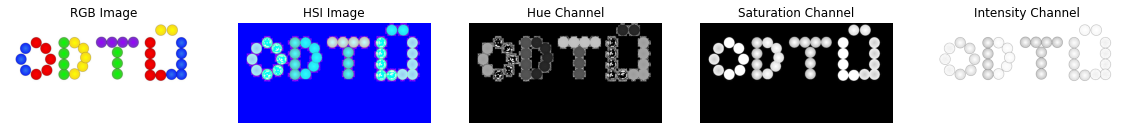

In [ ]:
# Convert RGB image to HSI image and visualize hue, saturation, intensity channels
from skimage import io, color
import matplotlib.pyplot as plt
import numpy as np

!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9/odtu.jpg
img1 = io.imread("odtu.jpg") 
img_hsi = color.rgb2hsv(img1)

plt.figure(figsize=(20,8))

plt.subplot(151); 
plt.imshow(img1); 
plt.title('RGB Image'); 
plt.axis('off')

plt.subplot(152); 
plt.imshow(img_hsi); 
plt.title('HSI Image'); 
plt.axis('off')

plt.subplot(153); 
plt.imshow(img_hsi[:,:,0],cmap='gray'); 
plt.title('Hue Channel'); 
plt.axis('off')

plt.subplot(154); 
plt.imshow(img_hsi[:,:,1],cmap='gray'); 
plt.title('Saturation Channel'); 
plt.axis('off')

plt.subplot(155); 
plt.imshow(img_hsi[:,:,2],cmap='gray'); 
plt.title('Intensity Channel'); 
plt.axis('off')

### Other Color Systems

  

There are many versions of the above mentioned color systems, developed for specific application domains. For example, [YUV color system](https://en.wikipedia.org/wiki/YUV) is used in some digital video and JPEG and MPEG compression.

  

Another popular system is YIQ color system, which is used for TV transmission, because of its good compression properties. In the [YIQ color system](https://en.wikipedia.org/wiki/YIQ), Y represents the luminance, which encodes the intensity values of monochrome images, used for black and white TV signal transmission. I and Q represent the chromaticity information, defined below:

$$I= Red-Cyan$$

$$Q= Magenta -Green.$$

  

A list of color spaces can be found in [https://en.wikipedia.org/wiki/List_of_color_spaces_and_their_uses](https://en.wikipedia.org/wiki/List_of_color_spaces_and_their_uses) .



### Conversion Between the Color Systems

Given an image in a color system we can convert it into a desired color system in order to implement in an image processing algorithm. Similarly, once we develop our algorithms in a color system, it is possible to convert the output image into another color system for display or storage purposes.

Conversion between RCB and CMY systems is very easy. From the definition of CMY color system we know that,

$$\begin{bmatrix}C\\ M \\ Y \end{bmatrix}= \begin{bmatrix}1\\ 1 \\ 1 \end{bmatrix}- \begin{bmatrix}R\\ G \\ B \end{bmatrix},$$

It is, also, possible to obtain YIQ color representation by using RGB and CMY color systems, as follows;

An approximate linear transformation from RGB to YIQ:

$$\begin{aligned} Y = 0.30R + 0.59G + 0.11B \\ I = 0.60R - 0.28G - 0.32B \\ Q = 0.21R - 0.52G + 0.31B\end{aligned}$$

In the above conversion, we often use the Y channel for color-to-gray tone conversion.

However, the conversion of an RGB image into an HSI image and vise versa, requires some tedious derivations. The result of the derivations are given below:

$$\begin{aligned}I &= \frac{1}{3}(R + G+B)\\ H &= \cos^{-1}\{ \frac{\frac{1}{2}[(R-G)+(R-B)]}{[(R-G)^2+(R-B)(G-B)]^{\frac{1}{2}}}\} \\ S&=1-\frac{3}{(R+G+B)}[min(R,G,B)]\end{aligned}.$$

It is, also, possible to define linear transformations between the color systems.from RGB to YIQ


### Color Normalization and Chromaticity Diagrams

  

Recall that, human visual system first decomposes the irradiated light from an object surface into two major components: Chrominance and luminance. Chrominance is the color information generated by the three types of cones, coded in three primary colors. Luminance is generated by the rods by capturing the monochromatic information. The HSI color system separates the chrominance (hue and saturation) and Luminance (Intensity). This representation generates a three dimensional color space, as we have seen in the previous section.

  

**Motivating Question:** Can we define a color system in a two dimensional space, where colors can be represented for a given luminance value?

  

In 1931, [International Commission on Illumination](https://en.wikipedia.org/wiki/International_Commission_on_Illumination) (CIE) suggested a normalized color system, called CIE system, which reduces the three dimensional color cube into two dimensions, by considering the above mentioned characteristics of human visual perception. Let us briefly summarize CIE color system:

  

Suppose that we are given a k-bit image for the $R, G, B$ channels of a color system. This means that each pixel is represented by an integer between $[0 , 2^k-1]$. We can normalize each channel as follows;

  

$$\begin{aligned} \text{normalized red } r &= R/(R+G+B) \\ \text{normalized green } g &= G/(R+G+B) \\ \text{normalized blue } b &= B/(R+G+B)\end{aligned}.$$

  

**Note:** In the above normalization, $r, g$ and $b$ are the measures of the percentage of each primary color within a given color.

  

**Exercise:** Given a color c = [30 20 250], in an RGB color system, find the percentage of each R,G,B color component in this color. What color is this?

  

**Answer:** Recall that percentage of each primary color can be obtained from the normalized colors, as follows:
$$\begin{aligned}  r &= R/(R+G+B) \\  g &= G/(R+G+B) \\ b &= B/(R+G+B)\end{aligned}.$$
  
  
Thus, r= 10% , g= 15% b= 75%.

  Therefore,  color $c$ mostly consists of blue and a little bit of green and a very tiny bit of red.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/3.png" height=100px></p></figure>

  
  



  
  

**Note:** There is an implicit relationships among the r, g, b coordinates

$$r+g+b=1.$$

  

This relationship makes one of the three primary colors dependent on the other two. In other words, the dimension of the color space is reduced to two, by simply computing one of the primary color from the other two independent colors, as follows;

  

$$g= 1-r-b.$$

  

Therefore, if we plot a color space in two dimensions, with two primary colors, namely, $r$ and $b,$ then, for each pair of $r$ and $b$ in this space, we can compute the corresponding value of $g$ from the above relation. This representation is called a [chromaticity diagram](https://en.wikipedia.org/wiki/Chromaticity).

  

Interestingly, it is observed that luminance of green color is higher than that of blue and red. Therefore, the relative percentage of green, $g$ also reflects the relative percentage of luminance. CIE chromaticity diagram is shown in Figure 22.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image20.png" height=600px><figcaption>Figure 22: CIE color space chromaticity diagram. This diagram displays the maximally saturated bright colors that can be produced by a [computer monitor](https://en.wikipedia.org/wiki/Computer_monitor) or [television set](https://en.wikipedia.org/wiki/Television_set). (Courtesy of General Electric Co., Lamp Business Division. ) </figcaption></p></figure>

  

In the chromaticity diagram, the boundaries correspond to the most saturated colors. White is indicated around the center of the diagram.

  

**Note:** The point of equal energy is the white light, this point is called CIE white. As we move towards the boundaries we get more and more saturated colors. colors are not straight lines but slightly bended curves.

  


### Color in Image Processing

Color information is very helpful in increasing the quality of image processing algorithms in most of the application domains. For example, we may need to retrieve outdoor images, from a database. It is expected that outdoor images are more likely to contain sky and trees. Thus, searching  regions  of blue and green colors may help to retrieve outdoor images with the sky and trees. In order to retrieve regions with specific color properties, we can segment images by partitioning it into regions with similar colors. We can, then  recognize the objects in an image using the color information.


We may also compare color histograms of the images and measure the similarities between them, for retrieving similar images from a database. 
  

In the following, we extend some of the monochromatic image processing methods we have seen so far, to color image processing. First, we suggest methods to define color histograms. Then, we suggest some histogram similarity metrics. Finally, we suggest simple methods for object recognition, segmentation, face detection and filtering, for color images

  


#### Color Histograms

Recall that gray scale histograms are very helpful to represent the brightness content of an image. Techniques, such as histogram thresholding, histogram equalization and histogram specification can be developed to enhance an image or detect a specific object described by its color content. Histogram techniques are very handy for a wide range of applications for image enhancement. Histogram processing has many advantages:

-  Histograms are easy and fast to compute.

- Histograms can be considered as the normalization of different size images to the same number of color bins. Thus, the color content of the images with different sizes can be easily compared by their histograms. 

-  Histograms provide a wide range of information about the image, such as, quality of image, illumination conditions, color content etc.

**Motivating Question:** How to create a color histogram with pixel color values, represented by a three dimensional vector, in a color space?

Recall that in a monochrome image, the histogram is defined as the frequency of each gray value, $r_i$. Formally,

$$h(r_i) = \text{Number of pixel with the brightness value, } r_i.$$

In a color image, each pixel has a three dimensional color vector, in a predefined color space, such as RGB, CMY or HSI spaces. We need to generate a color histogram, which measures the number of each color. There are many ways of generating a color histogram:

-  We can create a two dimensional histogram, $h(r_i,b_i)$, defined as

$$h(r_i, b_i) = \text{Number of pixel with the pair, } (r_i, b_i),$$

using the normalized CIE color space, in the chromaticity diagram. We can, also, use two of the three primary colors, such as Hue and Saturation. Figure 23 (middle) shows the two dimensional histogram of the image, using Hue and Saturation components of the HSI color space.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/4.png" height=200px><figcaption>

Figure 23: An image (left), its two dimensional color histogram, $h(H,S)$ with respect to Hue and Saturation (middle) and its three dimensional histogram, $h(H_i,S_i, I_i)$, represented by a heat map in the HSI color space.</figcaption></p></figure>

-  We can create a three dimensional histogram, $h(r_i,g_i, b_i)$, defined as

$$h(r_i, g_i, b_i)) = \text{Number of pixel with the triplet, } (r_i, g_i, b_i).$$

Each color point in Figure 23 (right) shows the [heat map](https://en.wikipedia.org/wiki/Heat_map#:~:text=A%20heat%20map%20(or%20heatmap,clustered%20or%20varies%20over%20space.) value of a relative frequency of a color, in a color coordinate.

-  We can create an independent histogram for each primary color and plot them separately for any color space. This approach enables us to analyze the content of each color band. Figure 24 shows the color histogram of an image for R, G and B channels.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/5_tolu.png" height=200px><figcaption>Figure 24: RGB color histogram of an image. The histogram of each color band is plotted separately. Each color band is plotted separately. </figcaption></p></figure>

-  We can define a pseudo color code for each color in the image and count their number of the color corresponding to that particular pseudo-code. For example, to create a 64 bin histogram, we group the colors under 64 bins. Then, we code the colors at each bin by its bin number.

**Exercise**: How do you generate a 64 bin color histogram for an 24 bit/pixel RGB color image?

**Answer:**

For each channel, we have 8 bits allocation per pixel. To generate a histogram with 64 bins, we take the most significant 2 bits for each channel, which gives 2x3 bits per pixel, which generates 64 pseudo-codes for the colors.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image34.png" height=400px><figcaption>

Figure 25: 64-bin histograms of two color images:
Take 2 most significant bits in R,G and B bands to obtain $2^6=64$ color codes</figcaption></p></figure>

  



### Measuring Image Similarity by Histograms
Images with the similar  content provides  important information in many image processing applications. For example, we may need to retrieve images, which contain a particular object in an image database. 

**Motivating Question:** How do we measure the similarity between images?
Similarity is a very crucial concept, in measure theory, yet there is no well-defined measure which can be used to measure the similarity of images. A very simple and robust way of comparing two images is to compare and measure the similarity of their color histograms.

**Motivating Question:** How can we measure the similarity between the color histograms?
In the context of this course we provide three metrics, for measuring histogram similarity, namely, Kulback Leibler, divergence, Sum of Square Error and Histogram Match, as explained below.


#### 1. Kullback Leibler Divergence
Recall that the normalized histogram approximates the **probability density function, $p(r_i)$**, when we take the color palette $r_i,$ for $i=1,..., (L-1)$ of an image as a random variable. Then, the similarity between the two probability density function, $p(r_i)$ and $q(r_i)$, can be measured by

  

$$KL[ p(r_i), q(r_i)] = \sum_{i=1}^{L-1}{p(r_i)\log{p(r_i)/q(r_i)}}.$$

  

[Kullback–Leibler divergence](https://en.wikipedia.org/wiki/Relative_entropy) is interpreted as the average difference of the number of bits required for encoding the pixel colors in $p(r_i)$ and $q(r_i)$.

  

**Note:** Kullback Leibler Divergence, $KL[ p(r_i), q(r_i)] = 0$ indicates that the two density functions are identical.



#### 2. Sum of Square Error

  

Another measure between two histograms, $h(r_i)$ and $g(r_i)$, is the sum of squared error defined as follows,

  

$$E = \sum_{i=1}^{L-1}{[h(r_i)-g(r_i)]^2}.$$

  

Sum of square error metric, takes the color-wise difference and adds all the square differences. Although it is easy to measure, it is a rather poor metric compared to Kulback-Leibler divergence.

  



### 3. Intersection and Match

  

One may directly measure the amount of intersection by computing the overlaps in two color histograms, as defined below;

  

$$\text{intersection}(h(r_i), g(r_i)) = \sum_{i=1}^{L-1}{\min{ [h(r_i), g(r_i)]}}.$$

  

Then, the intersection can be further normalized to measure the match between the two histograms, as follows;

  

$$\text{match}(h(r_i), g(r_i)) = \frac{\sum_{i=1}^{L-1}\min[ h(r_i), g(r_i)] }{\sum_{j=1}^{K}h(r_i)} $$

  

**Note:** Unfortunately, the above metrics, namely, Kulback Leibler divergence and Sum of Square Error and Match do not always measure perceptual similarities between the images. Therefore, one needs to pay special attention for the consistency of histogram similarity and perceptual similarity of images.

  
  
  


### Content Based Image Retrieval (CBIR)

  

Given a query image, searching the similar images in a large database is called Content Based Image Retrieval (CBIR) problem.

  

Histogram similarity measures given in the previous section is widely used in CBIR systems.

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image39.jpeg" height=400px><figcaption>Figure 26: Top left image is query image. The others are retrieved by having similar color histograms, using a histogram matching measure. </figcaption></p></figure>

  



### Object Recognition

  

Consider a specific image database, where each image consists of a single object. We can use color histograms to classify images, if the objects can be discriminated by colors.

  

For example, in a fruit juice factory, there are only apples and oranges on a conveyor belt. Suppose that we are asked to discriminate the two types of fruits in the images taken by a camera at the top of the belt.

  

**Motivating Question:** How do we design an object recognition algorithm using the color histogram?

  

The above problem requires a priori information about the color content of apples and oranges. We know that apples are green and/or red in hue, while the oranges have orange hue. Therefore, the best color space to design an algorithm is to be HSI space, where we can directly analyze the hue histogram. A typical histogram for apple and orange is shown in Figure 27. If we analyze the histograms of orange and apple in this figure, we notice that the intensity and saturation histograms are very similar for both apples and oranges. However, Hue is the discriminating band.

  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image40.jpeg" height=300px><figcaption>Figure 27: Separate HSI histograms for apples (left) and oranges (right) used by IBM’s VeggieVision for recognizing produce at the grocery store checkout station. The top row shows the Hue, middle row shows the saturation and the bottom row shows the intensity. Comparison of these three channel histograms show
that the discriminating feature is the Hue channel. </figcaption></p></figure>

  
  



### Color Clustering by K-means Algorithm

  

Color clustering is the task of grouping the colors in the palette of an image with respect to a similarity predicate.

  

**Goal:** Suppose that, we have an image with $L$ colors. Our goal is to cluster these colors under $K$ groups where $K\lt L$, such that the similar colors fall into the same group.

  

There are a large variety of algorithms for clustering the colors. In the following we provide one of the most popular color clustering algorithms, called K-Means Clustering.

  

**Note:** Color clustering algorithms are implemented in a predefined color space. Most of the time the colors are represented in a three dimensional space. However, depending on the application the dimension of color space can be as large as a couple of hundred dimensional, for multispectral images.

  

The following color clustering algorithm is based on the RGB color space.

  
  
  

**Algorithm: K-Means Clustering**

  

Input: A color image with $L$ colors, in RGB space..

Output: An image with K colors.

  

Step 1: Set $ic$ (iteration count) to 1.

  

Step 2: Choose randomly a set of K- color mean vectors

$$m_1(1), …, m_K(1),$$

  

where $m_k (1)= [r_k(1), g_k(1), b_k(1)], for \quad k=1,....,K$ .

  

Step 3: For each color vector $x_i = [r_i, g_i, b_i]$, compute the Eucledean distance between the color vector $x_i$ and the means, $m_1(ic), …, m_K(ic),$ as follows;

  

$$D( m_k(ic), x_i) = \sqrt{(r_k(1)-r_i)^2+ (g_k(1)-g_i)^2+ (b_k(1)- b_i)^2},$$

  

for all $k=1,…K$ and assign $x_i$ to the cluster $C_j$ with the nearest mean. where $D( m_k(ic), x_i)$ is smallest.

  

Step 4: Increment $ic$ by 1, update the cluster by taking the arithmetic average of the pixel colors who belongs to the cluster, as follows,

  
  

$$m_k(ic) = 1/N_k \sum^{N_k}_{i=1} x_i,$$

  

where $N_k$ is the number of the color vectors, at iteration $ic$, in cluster $k$.

  

means to get $m_1(ic), …, m_K(ic)$,

Step 5: Repeat steps 3 and 4 until

$$C_k(ic) = C_k(ic+1), \forall k .$$

  

K-means clustering algorithm, first, assigns arbitrary cluster mean values for K- colors and iteratively updates the cluster mean colors by measuring the Euclidean distance between the mean colors and the pixel colors. At any iteration count, $ic$, pixels are assigned to the cluster with the nearest mean. Once all the pixels are assigned to a cluster, then the new mean values are computed. The algorithm halts when there are no more chances in the cluster-mean colors.

  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/6.png" height=250px><figcaption>Figure 28: A typical output of K-means color clustering algorithm, for a given image, in three dimensional color space. For this particular example K=5 mean colors.</figcaption></p></figure>

  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image47_tolu.png" height=300px><figcaption>

Figure 29: (left) Original Image. (Middle) The output of color clustering  by K-Means, for $K=5 $. (Right) Output of  color clustering by K-Means for $K=3.$ </p></figure>

  

Figure 29 shows K-means clustering output of a color image. Notice that similar colors are nicely grouped under the same regions.

  
  



### Face Detection

  
Detection of the human faces in an image database is a classical pattern recognition problem. One pragmatic approach to face detection is to discriminate the skin color from the rest of the object color in images.The normalized RGB space,(CIE color space of two dimensions) is a very convenient space to discriminate the skin color from the color of other objects, as indicated in Figure 30. In this plot, purple (normal faces under good illumination) , cyan (faces under shadow) and yellow( faces with beard) show the regions corresponding to the face pixels. The rest of the object colors are indicated by red and blue.

  

**Note:** The color of the face pixels are clustered around the same color regions.

Using the plot of Figure 30, a simple face detection algorithm can be developed as described below:

  

>**Algorithm: Face Detection**
>>
>>Input: Face images with labeled pixels. Labels: l1 =non-face pixels, l2= normal face pixels, l3= face pixels under shadow, l4= face pixels with beard.
>>
>>Output: Bounding rectangle of face.
>>
>>Step 1: Plot the labeled pixels of several face images on the normalized RGB space,(CIE color space of two dimensions) .
>>
>>Step 2: Cluster the pixels with similar color under 5 groups, using the K-means color clustering method.
>>
>>Step3: Find the group which is the most similar to the skin color(s). Index this group as skin cluster.
>>
>>Step 5: Find the largest region in the image corresponding to the color of the skin cluster.
>>
>>Step 6: Find the bounding box of the largest region and label it as face.

  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image44.jpeg" height=400px><figcaption>

Figure 30: The pixels of a set of images with face  is clustered by k-Means method,  in 2-dimensional color coordinate system with  normalized red vs normalized blue.  The number of clusters is set to  $K=6$.  Magenta cluster shows skin color samples from several people. Cyan and yellow clusters show skin in shadow or behind a beard. Red, blue and  green clusters correspond other regions. </figcaption></p></figure>

  
  
  

The output of the face detection algorithm given above is shown for two faces, in Figure 31. The figure shows two faces (left), the pixels are clustered under five most similar color groups (middle) and the bounding box of the largest region of the image with skin color, labeled as face (right).

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image45.png" height=400px><figcaption>Figure 31: Face extraction examples: (left) input image, (middle) labelled image, (right) boundaries of the extracted face region. (all work contributed by Vera Bakic)</figcaption></p></figure>

  
  





## Color Image Enhancement

  

Recall that, we enhance an image by filtering techniques in space and/or frequency domains for monochrome images. Filtering the color images can be considered as the trivial extension of the monochrome images. All we can do is to apply the filtering methods in three different bands and put them together. However, sometimes it is more effective and practical to convert an image into HSI color space and process just the intensity channel. There may be some differences of the filtering techniques depending on the underlying color space. For example, consider filtering the Lena image: If we employ an averaging filter in RGB and the intensity channel of HSI spaces,we obtain the outputs of Figure 32 a and b). Visual inspection reveals that the outputs are very similar. When we take the difference of two outputs, we observe that they are not the same. Those minor differences are not significant in practical problems.

  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image48.png" height=250px><figcaption>

  

Figure 32: Image smoothing with a $5\times 5$ averaging mask. (a) Result of processing each RGB component image. (b) Result of processing the intensity component of the HSI image and converting to RGB. (c) Difference between the two results. (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  

Similar results can be observed in color image sharpening filters. For example, consider the output of an image sharpening algorithm using a Laplacian operator, applied in two different color representations of the same image, as shown in Figure 33. We can apply this filter separately to three different channels of the R, G and B components or we can just apply the fiter to the Intensity channel of HSI color space. Visual inspection reveals that the results are very similar. However, we observe minor changes, when we take the difference between two images.

  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image49.png" height=250px><figcaption>Figure 33: Image sharpening with the Laplacian. (a) Result of processing each RGB channel. (b) Result of processing the intensity component of the HSI image and converting to RGB. (c) Difference between the two results. (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  
  
  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image50.png" height=400px><figcaption>Figure 34: (a) RGB image (b) Gradient computed in RGB color vector space. (c) Gradients computed on a per-image basis and then added. (d) Difference between (b) and (c). (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image51.png" height=200px><figcaption>Figure 35: Component gradient images of the color image. (a) Red component, (b) green component, and (c) blue component. These three images were added and scaled to produce the image in Figure 35-(c). (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  
  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W9-Color/image52.png" height=500px><figcaption>Figure 36: (a)-(c) Red, green and blue component images corrupted by additive Gaussian noise of mean 0 and variance 800. (d) Resulting RGB image. Compare (d) with Figure 35-(a) (From the book by R. Gonzales, R.Woods)</figcaption></p></figure>

  

**Note:** Image enhancement algorithms result in a visually meaningful outputs on **HSI color space,** since this color space is consistent with the human visual system.

# Chapter Conclusion

What is color? How do we perceive and process it in Human Visual System? How can we mathematically represent it, so that we can process color images? How can we adopt the monochrome Image Processing algorithms developed in the previous chapters to color images?

In this chapter, we saw that color is a set of codes generated in our brain. We, somehow, mix the three primary colors, coded at the output of three types of cones  located in  retina, to generate millions of colors. Furthermore, we take the difference of intensity values between the focus of attention and its background to perceive  colors. Thus, we do not see the actual light reflectances from the object surface, but just the differences between these reflectances.

Three color theory of T. Young suggests that most of the  perceivable colors can be generated by taking the linear combination of three primary colors. Thus, mathematically, we represent a color by a three dimensional vector in a color space, spanned by three primary colors. There are many different combinations of primary colors, in color theory. The most popular ones are the red, green and blue primary colors, which span the RGB color space  and cyan, magenta and yellow primary colors, which span CMY color space. In both color spaces, we define a color cube, where each point corresponds to a perceivable color, represented by the linear combination of the three primary colors. Since it is quite simple and efficient to represent colors, most of the image acquisition and display devices generate colors with the three color theory. 

Unfortunately, Human Visual System generates colors by a series of very complicated,  yet not well-understood  neural processes. Thus, taking the linear combination of vectors fall too short for generating colors from three primary colors. Thus,  both RGB and CMY color spaces are not very convenient for developing Image Processing algorithms. In order to avoid the inconsistencies of RGB and CMY color systems, a relatively more convenient color space, called HSI color space is suggested, where a color is decomposed into its Hue, Saturation and Intensity components. Hue and Saturation correspond to chrominance generated by the cones, whereas the intensity corresponds to luminance, generated by the rods. 

We applied the image enhancement techniques, such as filtering and point operations, to three channels of colors separately, in RGB and CMY spaces. However, a more practical way is to use HSI color space and apply the enhancement to just the intensity (I) channel. 

Finally, we defined color histograms and we observed  that color histograms are very useful for a wide range of Image Processing and Computer Vision applications, such as object detection, recognition, segmentation  and content based image retrieval.